In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/metrics.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')
df.describe()

Loaded 115729 rows, 4 columns


,timestamp,cpu_percent,ram_percent,disk_percent
count,115728,115729.000000,115729.000000,115729.000000
mean,2026-05-17 15:18:23.829151232,4.511261,85.123795,25.065608
min,2026-05-15 12:26:56,0.000000,20.400000,22.300000
25%,2026-05-16 21:52:38,2.800000,81.300000,25.300000
50%,2026-05-17 15:40:01.500000,3.800000,88.500000,25.500000
75%,2026-05-18 10:07:00.249999872,4.500000,92.200000,25.700000
max,2026-05-18 16:05:03,94.200000,98.400000,25.900000
std,NaN,5.628705,10.267063,1.122296


In [3]:
df = df[(df['cpu_percent'] > 0) & (df['ram_percent'] > 0)]
df = df.drop_duplicates(subset='timestamp')
print(f'Clean rows: {len(df)}')

Clean rows: 66870


In [4]:
df.describe()

,timestamp,cpu_percent,ram_percent,disk_percent
count,66869,66870.000000,66870.000000,66870.000000
mean,2026-05-17 16:06:10.534941696,3.993970,83.153993,25.083851
min,2026-05-15 12:26:56,0.300000,20.400000,22.300000
25%,2026-05-17 10:23:55,2.800000,77.800000,25.400000
50%,2026-05-17 16:27:52,3.500000,86.600000,25.500000
75%,2026-05-18 10:20:22,4.300000,91.400000,25.800000
max,2026-05-18 16:05:03,92.900000,98.200000,25.900000
std,NaN,4.839254,11.129249,1.117526


In [5]:
len(df)

66870

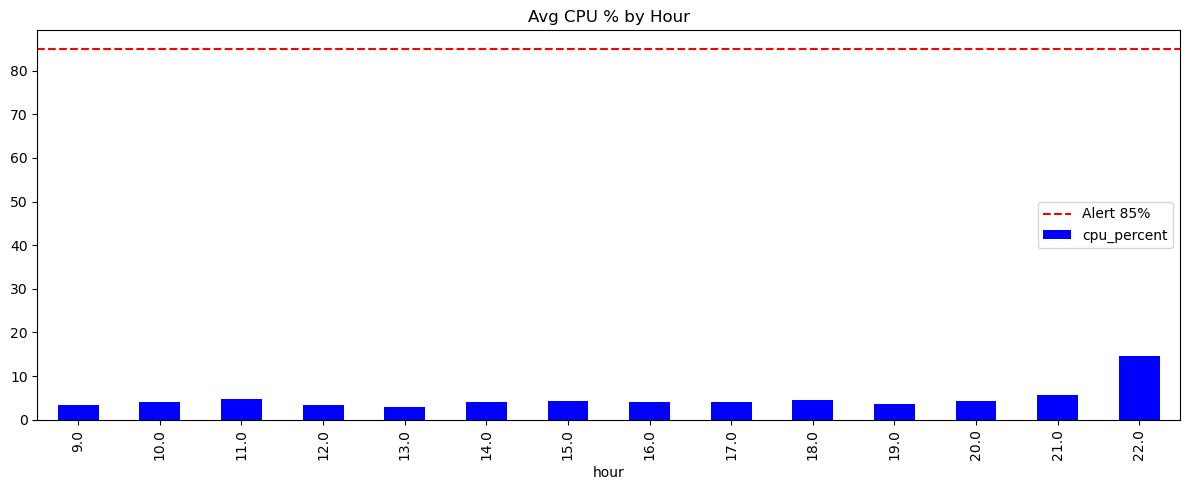

In [6]:
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby('hour')['cpu_percent'].mean()
hourly.plot(kind='bar', title='Avg CPU % by Hour', color='Blue', figsize=(12,5))
plt.axhline(y=85, color='red', linestyle='--', label='Alert 85%')
plt.legend(); plt.tight_layout()
plt.savefig('cpu_by_hour.png'); plt.show()

In [7]:
summary = df.groupby(df['timestamp'].dt.date).agg(
    avg_cpu  = ('cpu_percent', 'mean'),
    max_cpu  = ('cpu_percent', 'max'),
    avg_ram  = ('ram_percent', 'mean'),
    max_disk = ('disk_percent', 'max')
).reset_index()
summary.to_excel('daily_summary.xlsx', index=False)
print('Exported to daily_summary.xlsx')

Exported to daily_summary.xlsx


In [8]:
import sqlite3
conn = sqlite3.connect('data/metrics.db')

In [9]:
# Query 1: Average CPU per hour
q1 = '''SELECT strftime('%H', timestamp) AS hour,
               ROUND(AVG(cpu_percent), 2) AS avg_cpu
        FROM metrics GROUP BY hour ORDER BY hour'''
pd.read_sql(q1, conn)

,hour,avg_cpu
0,None,29.10
1,09,3.47
2,10,4.19
3,11,4.95
4,12,3.90
5,13,2.93
6,14,4.39
7,15,4.53
8,16,4.05
9,17,4.44


In [10]:
# Query 2: Top 10 high CPU events
q2 = '''SELECT * FROM metrics WHERE cpu_percent > 80
        ORDER BY timestamp DESC LIMIT 10'''
pd.read_sql(q2, conn)

,timestamp,cpu_percent,ram_percent,disk_percent
0,2026-05-18 14:28:17,92.9,53.0,25.4
1,2026-05-18 14:00:02,90.7,90.9,25.8
2,2026-05-18 14:00:02,85.4,90.2,25.8
3,2026-05-18 14:00:02,82.8,89.5,25.8
4,2026-05-18 14:00:01,82.7,91.9,25.8
5,2026-05-18 14:00:01,83.6,91.8,25.8
6,2026-05-18 11:46:38,84.9,46.7,25.8
7,2026-05-18 11:05:02,87.2,81.8,25.8
8,2026-05-18 11:05:02,87.3,81.7,25.8
9,2026-05-18 11:05:01,80.7,82.8,25.8


In [11]:
# Query 3: Daily aggregated summary
q3 = '''SELECT DATE(timestamp) AS day, COUNT(*) AS total_readings,
               ROUND(AVG(cpu_percent),1) AS avg_cpu,
               MAX(disk_percent) AS max_disk
        FROM metrics GROUP BY DATE(timestamp) ORDER BY day DESC'''
pd.read_sql(q3, conn)

,day,total_readings,avg_cpu,max_disk
0,2026-05-18,30524,4.7,25.9
1,2026-05-17,53726,4.9,25.7
2,2026-05-16,30974,3.7,25.5
3,2026-05-15,21,0.5,22.8
4,None,1,29.1,25.7


In [30]:
df.to_csv('cleaned_metrics.csv', index=False)